In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
import h5py
import matplotlib.gridspec as gridspec
from scipy.ndimage import zoom
from scipy import interpolate

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPUs Available: {len(tf.config.list_physical_devices('GPU'))}")

2026-01-28 09:28:09.448830: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769592489.659487      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769592489.723214      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769592490.201740      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769592490.201772      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769592490.201775      55 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0
GPUs Available: 2


In [2]:
def load_paired_reynolds_multi_3channel(file_paths, lr_dim, hr_dim):
    """
    Loads data from multiple HDF5 files and stacks u, v, p as 3 channels.
    Each sample is now (H, W, 3) instead of separate components.
    
    Returns:
        x_lr: (N, lr_dim, lr_dim, 3) - low resolution fields
        x_hr: (N, hr_dim, hr_dim, 3) - high resolution fields
        reynolds_numbers: (N,) - Reynolds number for each sample
        bc_types: (N,) - boundary condition type for each sample
    """
    xs_lr_all, xs_hr_all, used_res_all, bc_types_all = [], [], [], []
    
    for file_path in file_paths:
        print(f"\n📂 Loading from: {file_path}")
        
        try:
            with h5py.File(file_path, 'r') as f:
                all_keys = list(f.keys())
                if not all_keys: 
                    print(f"⚠️  File is empty, skipping.")
                    continue
                
                re_numbers_in_file = sorted(list(set(int(k.split('_')[0][2:]) for k in all_keys if k.startswith("Re"))))
                print(f"   Found Reynolds numbers: {re_numbers_in_file}")
                
                # Detect BC type
                first_group = f[all_keys[0]]
                bc_type = first_group.attrs.get('bc_type', 'unknown')
                print(f"   BC Type: {bc_type}")
                
                for Re in re_numbers_in_file:
                    g_lr = f"Re{Re}_mesh{lr_dim}x{lr_dim}"
                    g_hr = f"Re{Re}_mesh{hr_dim}x{hr_dim}"
                    
                    if g_lr in all_keys and g_hr in all_keys:
                        # Check if all components exist
                        if all(comp in f[g_lr] and comp in f[g_hr] for comp in ['u', 'v', 'p']):
                            # Load raw data and check its shape
                            lr_u_raw = f[g_lr]['u'][()].astype(np.float32)
                            lr_v_raw = f[g_lr]['v'][()].astype(np.float32)
                            lr_p_raw = f[g_lr]['p'][()].astype(np.float32)
                            
                            hr_u_raw = f[g_hr]['u'][()].astype(np.float32)
                            hr_v_raw = f[g_hr]['v'][()].astype(np.float32)
                            hr_p_raw = f[g_hr]['p'][()].astype(np.float32)
                            
                            # DEBUG: Print shape of first sample
                            if len(xs_lr_all) == 0:
                                print(f"\n   🔍 DEBUG - First sample shapes:")
                                print(f"      lr_u raw shape: {lr_u_raw.shape} -> reshaping to ({lr_dim}, {lr_dim})")
                                print(f"      hr_u raw shape: {hr_u_raw.shape} -> reshaping to ({hr_dim}, {hr_dim})")
                                print(f"      First few values of lr_u: {lr_u_raw[:10]}")
                            
                            # CRITICAL FIX: Reshape with Fortran order (column-major)
                            # HDF5 data from scientific simulations is often stored column-major
                            lr_u = lr_u_raw.reshape(lr_dim, lr_dim, order='F')
                            lr_v = lr_v_raw.reshape(lr_dim, lr_dim, order='F')
                            lr_p = lr_p_raw.reshape(lr_dim, lr_dim, order='F')
                            
                            hr_u = hr_u_raw.reshape(hr_dim, hr_dim, order='F')
                            hr_v = hr_v_raw.reshape(hr_dim, hr_dim, order='F')
                            hr_p = hr_p_raw.reshape(hr_dim, hr_dim, order='F')
                            
                            # Stack as (H, W, 3) - channels in order [u, v, p]
                            xs_lr_all.append(np.stack([lr_u, lr_v, lr_p], axis=-1))
                            xs_hr_all.append(np.stack([hr_u, hr_v, hr_p], axis=-1))
                            used_res_all.append(Re)
                            bc_types_all.append(bc_type)
                
                print(f"   ✅ Loaded {len([r for r in used_res_all if bc_types_all[len(used_res_all)-1] == bc_type])} samples from this file")
                
        except (IOError, OSError, FileNotFoundError) as e:
            print(f"⚠️  Error opening file: {e}")
            continue
    
    if len(xs_lr_all) == 0:
        print("\n⚠️ No data loaded. Creating dummy 3-channel data...")
        N = 20
        xs_lr_all = [np.random.randn(lr_dim, lr_dim, 3).astype(np.float32) for _ in range(N)]
        xs_hr_all = [np.random.randn(hr_dim, hr_dim, 3).astype(np.float32) for _ in range(N)]
        used_res_all = list(np.arange(50, 50*N+1, 50))
        bc_types_all = ['dummy'] * N
    
    print(f"\n📊 Total loaded: {len(xs_lr_all)} samples from {len(file_paths)} file(s)")
    print(f"   BC Type distribution: {dict(zip(*np.unique(bc_types_all, return_counts=True)))}")

    return (np.array(xs_lr_all, dtype=np.float32), 
            np.array(xs_hr_all, dtype=np.float32), 
            np.array(used_res_all), 
            np.array(bc_types_all))

In [3]:
def bicubic_interpolate_batch(x, target_size):
    """
    Bicubic interpolation for batched multi-channel images.
    XLA compilation is disabled at model level (jit_compile=False in compile()).
    
    Args:
        x: (N, H, W, C) tensor
        target_size: (target_H, target_W) tuple
    Returns:
        Interpolated tensor of shape (N, target_H, target_W, C)
    """
    return tf.image.resize(x, target_size, method='bicubic')

def normalize_per_channel_zscore(arr):
    """
    Z-score normalization per channel (u, v, p separately).
    
    Args:
        arr: (N, H, W, 3) array
    Returns:
        normalized_arr: (N, H, W, 3)
        stats: dict with keys 'u', 'v', 'p', each containing (mean, std)
    """
    normalized = np.zeros_like(arr)
    stats = {}
    
    for ch_idx, ch_name in enumerate(['u', 'v', 'p']):
        ch_data = arr[..., ch_idx]
        mean = np.mean(ch_data, dtype=np.float64)
        std = np.std(ch_data, dtype=np.float64)
        std = max(std, 1e-8)  # Avoid division by zero
        
        normalized[..., ch_idx] = (ch_data - mean) / std
        stats[ch_name] = (float(mean), float(std))
    
    return normalized, stats

def normalize_with_stats(arr, stats):
    """Apply pre-computed normalization statistics."""
    normalized = np.zeros_like(arr)
    for ch_idx, ch_name in enumerate(['u', 'v', 'p']):
        mean, std = stats[ch_name]
        normalized[..., ch_idx] = (arr[..., ch_idx] - mean) / std
    return normalized

def denormalize_with_stats(arr, stats):
    """Inverse normalization."""
    denormalized = np.zeros_like(arr)
    for ch_idx, ch_name in enumerate(['u', 'v', 'p']):
        mean, std = stats[ch_name]
        denormalized[..., ch_idx] = arr[..., ch_idx] * std + mean
    return denormalized

In [4]:
def gradient_difference_loss(y_true, y_pred):
    """
    Gradient Difference Loss (GDL) - enforces sharp gradients in flow fields.
    Computes L1 distance between spatial gradients.
    """
    # Compute gradients in x and y directions
    true_dx = y_true[:, :, 1:, :] - y_true[:, :, :-1, :]
    true_dy = y_true[:, 1:, :, :] - y_true[:, :-1, :, :]
    
    pred_dx = y_pred[:, :, 1:, :] - y_pred[:, :, :-1, :]
    pred_dy = y_pred[:, 1:, :, :] - y_pred[:, :-1, :, :]
    
    # L1 difference of gradients
    loss_x = tf.reduce_mean(tf.abs(true_dx - pred_dx))
    loss_y = tf.reduce_mean(tf.abs(true_dy - pred_dy))
    
    return loss_x + loss_y

def spectral_loss(y_true, y_pred):
    """
    Spectral Loss - matches frequency domain energy distribution.
    Uses FFT to compare high-frequency content preservation.
    """
    # Convert to complex for FFT
    y_true_complex = tf.cast(y_true, tf.complex64)
    y_pred_complex = tf.cast(y_pred, tf.complex64)
    
    # 2D FFT (apply to spatial dimensions)
    fft_true = tf.signal.fft2d(y_true_complex)
    fft_pred = tf.signal.fft2d(y_pred_complex)
    
    # Magnitude spectrum
    mag_true = tf.abs(fft_true)
    mag_pred = tf.abs(fft_pred)
    
    # L1 loss in frequency domain
    return tf.reduce_mean(tf.abs(mag_true - mag_pred))

class CompositeLoss(tf.keras.losses.Loss):
    """
    Composite loss: L1 + Gradient + Spectral
    Supports both fixed and adaptive weighting strategies.
    """
    def __init__(self, alpha=1.0, beta=0.1, gamma=0.05, adaptive=False, name='composite_loss'):
        super().__init__(name=name)
        self.alpha = alpha  # L1 weight
        self.beta = beta    # Gradient weight
        self.gamma = gamma  # Spectral weight
        self.adaptive = adaptive
        
        # Trackers for adaptive weighting
        if adaptive:
            self.l1_ema = tf.Variable(1.0, trainable=False)
            self.grad_ema = tf.Variable(1.0, trainable=False)
            self.spec_ema = tf.Variable(1.0, trainable=False)
            self.ema_decay = 0.9
    
    def call(self, y_true, y_pred):
        # Compute individual losses
        l1_loss = tf.reduce_mean(tf.abs(y_true - y_pred))
        grad_loss = gradient_difference_loss(y_true, y_pred)
        spec_loss = spectral_loss(y_true, y_pred)
        
        if self.adaptive:
            # Update exponential moving averages
            self.l1_ema.assign(self.ema_decay * self.l1_ema + (1 - self.ema_decay) * l1_loss)
            self.grad_ema.assign(self.ema_decay * self.grad_ema + (1 - self.ema_decay) * grad_loss)
            self.spec_ema.assign(self.ema_decay * self.spec_ema + (1 - self.ema_decay) * spec_loss)
            
            # Adaptive weights (inverse of EMA to balance magnitudes)
            alpha_adaptive = 1.0 / (self.l1_ema + 1e-8)
            beta_adaptive = 1.0 / (self.grad_ema + 1e-8)
            gamma_adaptive = 1.0 / (self.spec_ema + 1e-8)
            
            # Normalize weights to sum to 1
            total = alpha_adaptive + beta_adaptive + gamma_adaptive
            alpha_adaptive /= total
            beta_adaptive /= total
            gamma_adaptive /= total
            
            total_loss = alpha_adaptive * l1_loss + beta_adaptive * grad_loss + gamma_adaptive * spec_loss
        else:
            # Fixed weighting
            total_loss = self.alpha * l1_loss + self.beta * grad_loss + self.gamma * spec_loss
        
        return total_loss

# ==================== WEIGHTING CONFIGURATION ====================
# Choose ONE strategy by uncommenting the desired line:

# Option 1: Fixed weights (recommended to start)
# LOSS_CONFIG = {'alpha': 1.0, 'beta': 0.1, 'gamma': 0.05, 'adaptive': False}
# Start with PURE L1 loss:
LOSS_CONFIG = {'alpha': 1.0, 'beta': 0.0, 'gamma': 0.0, 'adaptive': False}
# Gradient/spectral losses might be causing artifacts
# Option 2: Adaptive weights (automatic balancing)
# LOSS_CONFIG = {'alpha': 1.0, 'beta': 0.1, 'gamma': 0.05, 'adaptive': True}
# ==================================================================

In [5]:
def conv_block(x, filters, kernel_size=3, activation='relu'):
    """Convolutional block: Conv2D -> BatchNorm -> Activation."""
    x = layers.Conv2D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(activation)(x)
    return x

def build_residual_unet(input_shape, base_filters=32, depth=3, activation='relu'):
    """
    Residual U-Net that predicts correction residuals.
    Uses bilinear upsampling + Conv2D instead of transposed convolutions.
    Optimized for power-of-2 dominant dimensions (20, 40, 80, 200, 400).
    
    Args:
        input_shape: (H, W, 3) - includes bicubic-interpolated input
        base_filters: Starting number of filters (e.g., 32)
        depth: Number of downsampling levels (3  to  32, 64, 128)
        activation: Activation function ('relu', 'swish', etc.)
    
    Returns:
        Model that outputs residual correction of same shape as input
    """
    inputs = layers.Input(shape=input_shape, name='unet_input')
    
    # Encoder (downsampling path)
    encoder_outputs = []
    x = inputs
    
    for i in range(depth):
        filters = base_filters * (2 ** i)
        x = conv_block(x, filters, activation=activation)
        x = conv_block(x, filters, activation=activation)
        encoder_outputs.append(x)
        
        if i < depth - 1:  # Don't downsample on last layer
            x = layers.MaxPooling2D(pool_size=2)(x)
    
    # Decoder (upsampling path)
    for i in range(depth - 2, -1, -1):
        filters = base_filters * (2 ** i)
        
        # Bilinear upsampling + Conv2D (more stable than transposed conv)
        x = layers.UpSampling2D(size=2, interpolation='bilinear')(x)
        x = layers.Conv2D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation(activation)(x)
        
        # Skip connection (direct concatenation - dimensions match with depth=3)
        x = layers.Concatenate()([x, encoder_outputs[i]])
        
        x = conv_block(x, filters, activation=activation)
        x = conv_block(x, filters, activation=activation)
    
    # Output: residual correction (same channels as input)
    residual = layers.Conv2D(input_shape[-1], 1, padding='same', name='residual_output')(x)
    
    return Model(inputs, residual, name='residual_unet')

class InterpolateRefineModel(Model):
    """
    Complete stage model: Interpolate -> Predict Residual -> Add.
    Output = Bicubic(input) + U-Net(Bicubic(input))
    """
    def __init__(self, unet_model, target_size, **kwargs):
        super().__init__(**kwargs)
        self.unet = unet_model
        self.target_size = target_size
    
    def call(self, inputs, training=False):
        # Step 1: Bicubic interpolation to target size
        interpolated = bicubic_interpolate_batch(inputs, self.target_size)
        
        # Step 2: Predict residual correction
        residual = self.unet(interpolated, training=training)

        residual = residual * 0.1  # Scale down residual to stabilize training
        
        # Step 3: Add residual to interpolated (residual learning)
        refined = interpolated + residual
        
        return refined

In [6]:
def train_stage(model, x_input, x_target, epochs, batch_size, loss_config, stage_name):
    """
    Train a single stage of the cascaded model with early stopping.
    
    Args:
        model: InterpolateRefineModel instance
        x_input: Input data (N, H_in, W_in, 3)
        x_target: Target data (N, H_out, W_out, 3)
        epochs: Number of training epochs
        batch_size: Batch size
        loss_config: Dict with loss parameters
        stage_name: Name for logging (e.g., "10->40")
    """
    print(f"\n{'='*60}")
    print(f"🚀 Training Stage: {stage_name}")
    print(f"   Input shape: {x_input.shape}, Target shape: {x_target.shape}")
    print(f"   Loss config: {loss_config}")
    print(f"{'='*60}")
    
    # Split into train/validation (85/15 split)
    n_samples = len(x_input)
    n_val = max(1, int(n_samples * 0.15))  # At least 1 validation sample
    n_train = n_samples - n_val
    
    # Create shuffled indices
    indices = np.random.permutation(n_samples)
    train_idx = indices[:n_train]
    val_idx = indices[n_train:]
    
    x_train = x_input[train_idx]
    y_train = x_target[train_idx]
    x_val = x_input[val_idx]
    y_val = x_target[val_idx]
    
    print(f"   Training samples: {n_train}, Validation samples: {n_val}")
    
    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=CompositeLoss(**loss_config),
        jit_compile=False  # Disable XLA compilation (ResizeBicubic not XLA-compatible)
    )
    
    # Create datasets
    train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
    train_dataset = train_dataset.shuffle(len(x_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    
    val_dataset = tf.data.Dataset.from_tensor_slices((x_val, y_val))
    val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    
    # Early stopping callback
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=50,  # Stop if no improvement for 50 epochs
        restore_best_weights=True,
        verbose=1,
        mode='min'
    )
    
    # Train with validation and early stopping
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=epochs,
        callbacks=[early_stopping],
        verbose=0
    )
    
    # Print training summary
    best_epoch = np.argmin(history.history['val_loss']) + 1
    best_val_loss = np.min(history.history['val_loss'])
    final_train_loss = history.history['loss'][-1]
    
    print(f"✅ Stage {stage_name} training complete.")
    print(f"   Best epoch: {best_epoch}/{len(history.history['loss'])}")
    print(f"   Best val_loss: {best_val_loss:.6f}")
    print(f"   Final train_loss: {final_train_loss:.6f}")
    
    return history

def evaluate_stage(model, x_input, x_target, stats, stage_name):
    """
    Evaluate a stage and compute MAE in physical units.
    """
    print(f"\n📊 Evaluating Stage: {stage_name}")
    
    # Predict
    predictions_norm = model.predict(x_input, verbose=0)
    
    # Denormalize
    predictions_real = denormalize_with_stats(predictions_norm, stats)
    target_real = denormalize_with_stats(x_target, stats)
    
    # Compute MAE per channel
    mae_u = np.mean(np.abs(target_real[..., 0] - predictions_real[..., 0]))
    mae_v = np.mean(np.abs(target_real[..., 1] - predictions_real[..., 1]))
    mae_p = np.mean(np.abs(target_real[..., 2] - predictions_real[..., 2]))
    mae_total = np.mean([mae_u, mae_v, mae_p])
    
    print(f"   MAE (u): {mae_u:.6f}")
    print(f"   MAE (v): {mae_v:.6f}")
    print(f"   MAE (p): {mae_p:.6f}")
    print(f"   MAE (avg): {mae_total:.6f}")
    
    return {'mae_u': mae_u, 'mae_v': mae_v, 'mae_p': mae_p, 'mae_avg': mae_total}

def plot_comparison(input_lr, target_hr, pred_hr, sample_idx, stage_name, stats, reynolds_num=None):
    """
    Plot comparison of low-res input, ground truth, and prediction.
    Shows all 3 channels (u, v, p) in separate rows.
    Uses contourf with levels=20 to match sr-ae-conv.ipynb plotting style.
    
    Note: Data orientation matches the original sr-ae-conv notebook exactly.
    """
    # Denormalize
    target_real = denormalize_with_stats(target_hr[sample_idx:sample_idx+1], stats)[0]
    pred_real = denormalize_with_stats(pred_hr[sample_idx:sample_idx+1], stats)[0]
    input_real = denormalize_with_stats(input_lr[sample_idx:sample_idx+1], stats)[0]
    
    fig, axes = plt.subplots(3, 4, figsize=(18, 12))
    channel_names = ['u-velocity', 'v-velocity', 'Pressure']
    cmap = 'RdBu'
    
    for ch_idx in range(3):
        # Input (interpolated for visualization)
        input_interp = bicubic_interpolate_batch(
            input_real[..., ch_idx:ch_idx+1][None, ...], 
            target_real.shape[:2]
        )[0, ..., 0].numpy()
        
        # Extract 2D data for each plot
        # Apply transpose (.T) to match correct geometry orientation
        data_input = input_interp.T
        data_target = target_real[..., ch_idx].T
        data_pred = pred_real[..., ch_idx].T
        diff = data_target - data_pred
        diff_max_abs = np.abs(diff).max()
        mae = np.mean(np.abs(diff))
        
        # Use contourf with levels=20 (matching old notebook style exactly)
        im0 = axes[ch_idx, 0].contourf(data_input, levels=20, cmap=cmap)
        fig.colorbar(im0, ax=axes[ch_idx, 0]).set_label("Field Value")
        axes[ch_idx, 0].set_title(f'Input (Interpolated)\n{channel_names[ch_idx]}')
        axes[ch_idx, 0].set_aspect('equal')
        
        im1 = axes[ch_idx, 1].contourf(data_target, levels=20, cmap=cmap)
        fig.colorbar(im1, ax=axes[ch_idx, 1]).set_label("Field Value")
        axes[ch_idx, 1].set_title(f'Ground Truth\n{channel_names[ch_idx]}')
        axes[ch_idx, 1].set_aspect('equal')
        
        im2 = axes[ch_idx, 2].contourf(data_pred, levels=20, cmap=cmap)
        fig.colorbar(im2, ax=axes[ch_idx, 2]).set_label("Field Value")
        axes[ch_idx, 2].set_title(f'Prediction\n{channel_names[ch_idx]}')
        axes[ch_idx, 2].set_aspect('equal')
        
        im3 = axes[ch_idx, 3].contourf(diff, levels=20, cmap=cmap, vmin=-diff_max_abs, vmax=diff_max_abs)
        fig.colorbar(im3, ax=axes[ch_idx, 3]).set_label("Error")
        axes[ch_idx, 3].set_title(f'Error | MAE: {mae:.6f}\n{channel_names[ch_idx]}')
        axes[ch_idx, 3].set_aspect('equal')
    
    # Create title with Reynolds number if provided
    if reynolds_num is not None:
        fig.suptitle(f'Stage {stage_name} - Re={reynolds_num}', fontsize=16)

    else:    
        plt.show()

        fig.suptitle(f'Stage {stage_name} - Sample {sample_idx}', fontsize=16)   
        plt.tight_layout(rect=[0, 0, 1, 0.97])

In [7]:
# ========================= USER CONFIGURATION =========================
# --- Progressive Cascade Configuration ---
LR_DIM = 10  # Starting low-resolution grid size
STAGE_DIMS = [20, 40, 80, 200, 400]  # Progressive stages (power-of-2 dominant)
# Alternative configurations (uncomment to try):
# STAGE_DIMS = [20, 40, 80, 150, 300, 400]  # Ultra-smooth (6 stages)
# STAGE_DIMS = [20, 40, 100, 200, 400]      # Include 100×100
# STAGE_DIMS = [40, 200, 400]               # Fewer stages (faster)

# --- Training Hyperparameters ---
EPOCHS_PER_STAGE = [300, 300, 400, 400, 500]  # Much longer training
# With small dataset, need more iterations to converge
# EPOCHS_PER_STAGE = [10, 10, 10, 10, 10]
BATCH_SIZE = 8
BASE_FILTERS = 16  # U-Net base filters (32, 64, or 128)
UNET_DEPTH = 2    # U-Net depth (3 levels: 32->64->128, perfect for 20/40/80/200/400)
ACTIVATION = 'swish'  # 'relu', 'swish', or 'leaky_relu'
PLOT_SAMPLES = True
OTHER_DETAILS = "progressive_residual_unet_trained only with single lid"

# --- Data File Paths ---
file_paths = [
    "/kaggle/input/re-50-1000-mesh-10-400-ch-5/simulation_result.h5",           # Replace with your actual paths
    "/kaggle/input/re-50-1000-mesh-10-400-ch-5/simulation_result_double_lid.h5"
]

# --- Reynolds Number Configuration per BC Type ---
reynolds_config = {
    "single_lid(u_top=1)": {
        "train": [50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700,750, 800],
        "test": [850],
    },
    "double_lid(u_top=1,u_bottom=1)": {
        "train": [50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700,750, 800],
        "test": [850],
    }
}
# ======================================================================

In [8]:
# Load data for each stage
print("\n" + "="*70)
print("📦 LOADING DATA FOR ALL STAGES")
print("="*70)

# We'll load data for 10, 40, 160, 400 resolutions
all_dims = [LR_DIM] + STAGE_DIMS
data_by_resolution = {}

for dim in all_dims:
    print(f"\n📂 Loading {dim}x{dim} resolution data...")
    x_data, _, res_data, bc_data = load_paired_reynolds_multi_3channel(
        file_paths, 
        lr_dim=dim, 
        hr_dim=dim  # Load same resolution (we'll pair them across resolutions later)
    )
    data_by_resolution[dim] = {
        'x': x_data,
        'res': res_data,
        'bc': bc_data
    }
    print(f"   Loaded shape: {x_data.shape}")


📦 LOADING DATA FOR ALL STAGES

📂 Loading 10x10 resolution data...

📂 Loading from: /kaggle/input/re-50-1000-mesh-10-400-ch-5/simulation_result.h5
   Found Reynolds numbers: [50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 850, 900, 950, 1000, 1050, 1100, 1150]
   BC Type: single_lid(u_top=1)

   🔍 DEBUG - First sample shapes:
      lr_u raw shape: (100,) -> reshaping to (10, 10)
      hr_u raw shape: (100,) -> reshaping to (10, 10)
      First few values of lr_u: [ 0.00050029 -0.00454239 -0.01622367 -0.02583434 -0.03385786 -0.03570393
 -0.02957708 -0.0189888  -0.00436537  0.00153212]
   ✅ Loaded 23 samples from this file

📂 Loading from: /kaggle/input/re-50-1000-mesh-10-400-ch-5/simulation_result_double_lid.h5
   Found Reynolds numbers: [50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 850]
   BC Type: double_lid(u_top=1,u_bottom=1)
   ✅ Loaded 40 samples from this file

📊 Total loaded: 40 samples from 2 file(s)
   BC Type d

In [9]:
# Diagnostic: Check data completeness across all resolutions
print("\n" + "="*70)
print("🔍 DIAGNOSING DATA COMPLETENESS")
print("="*70)

def check_data_completeness(data_by_resolution, all_dims):
    """
    Check which (Re, BC) combinations have data at ALL required resolutions.
    Returns a dict of complete samples and prints diagnostic info.
    """
    # Build a set of (Re, BC, dim) tuples that exist
    available_samples = set()
    for dim in all_dims:
        for idx in range(len(data_by_resolution[dim]['res'])):
            re = data_by_resolution[dim]['res'][idx]
            bc = data_by_resolution[dim]['bc'][idx]
            available_samples.add((re, bc, dim))
    
    # Find unique (Re, BC) combinations
    re_bc_pairs = set()
    for re, bc, dim in available_samples:
        re_bc_pairs.add((re, bc))
    
    # Check completeness for each (Re, BC) pair
    complete_pairs = []
    incomplete_pairs = []
    
    for re, bc in sorted(re_bc_pairs):
        dims_present = [dim for dim in all_dims if (re, bc, dim) in available_samples]
        missing_dims = [dim for dim in all_dims if (re, bc, dim) not in available_samples]
        
        if len(missing_dims) == 0:
            complete_pairs.append((re, bc))
        else:
            incomplete_pairs.append((re, bc, missing_dims))
    
    return complete_pairs, incomplete_pairs

# Run diagnostic
complete_samples, incomplete_samples = check_data_completeness(data_by_resolution, all_dims)

print(f"\n📊 Completeness Report:")
print(f"   Required resolutions: {all_dims}")
print(f"   Total (Re, BC) combinations found: {len(complete_samples) + len(incomplete_samples)}")
print(f"   ✅ Complete samples (all resolutions): {len(complete_samples)}")
print(f"   ⚠️  Incomplete samples (missing some): {len(incomplete_samples)}")

if incomplete_samples:
    print(f"\n⚠️  WARNING: Found {len(incomplete_samples)} incomplete samples!")
    print(f"   These will be EXCLUDED from training to avoid mismatched data.")
    print(f"\n   Incomplete samples (showing first 10):")
    for re, bc, missing in incomplete_samples[:10]:
        print(f"      Re={re}, BC={bc}  to  Missing resolutions: {missing}")
    if len(incomplete_samples) > 10:
        print(f"      ... and {len(incomplete_samples) - 10} more")

print(f"\n✅ Complete samples that will be used:")
for re, bc in complete_samples[:20]:
    print(f"      Re={re}, BC={bc}")
if len(complete_samples) > 20:
    print(f"      ... and {len(complete_samples) - 20} more")

print(f"\n{'='*70}")
print(f"✅ Diagnostic complete. Proceeding with {len(complete_samples)} complete samples.")
print(f"{'='*70}")


🔍 DIAGNOSING DATA COMPLETENESS

📊 Completeness Report:
   Required resolutions: [10, 20, 40, 80, 200, 400]
   Total (Re, BC) combinations found: 40
   ✅ Complete samples (all resolutions): 40
   ⚠️  Incomplete samples (missing some): 0

✅ Complete samples that will be used:
      Re=50, BC=double_lid(u_top=1,u_bottom=1)
      Re=50, BC=single_lid(u_top=1)
      Re=100, BC=double_lid(u_top=1,u_bottom=1)
      Re=100, BC=single_lid(u_top=1)
      Re=150, BC=double_lid(u_top=1,u_bottom=1)
      Re=150, BC=single_lid(u_top=1)
      Re=200, BC=double_lid(u_top=1,u_bottom=1)
      Re=200, BC=single_lid(u_top=1)
      Re=250, BC=double_lid(u_top=1,u_bottom=1)
      Re=250, BC=single_lid(u_top=1)
      Re=300, BC=double_lid(u_top=1,u_bottom=1)
      Re=300, BC=single_lid(u_top=1)
      Re=350, BC=double_lid(u_top=1,u_bottom=1)
      Re=350, BC=single_lid(u_top=1)
      Re=400, BC=double_lid(u_top=1,u_bottom=1)
      Re=400, BC=single_lid(u_top=1)
      Re=450, BC=double_lid(u_top=1,u_bottom=1

In [10]:
# Split data into train/test based on Reynolds config AND completeness filter
print("\n" + "="*70)
print("🎯 SPLITTING TRAIN/TEST DATA (with completeness filtering)")
print("="*70)

# Build completeness filter: only keep indices where (Re, BC) is in complete_samples
def build_completeness_mask(res_array, bc_array, complete_pairs):
    """Create mask that is True only for complete (Re, BC) combinations."""
    mask = np.zeros(len(res_array), dtype=bool)
    for re, bc in complete_pairs:
        mask |= (res_array == re) & (bc_array == bc)
    return mask

# Create train/test masks based on Reynolds config AND completeness
train_mask_10 = np.zeros(len(data_by_resolution[LR_DIM]['res']), dtype=bool)
test_mask_10 = np.zeros(len(data_by_resolution[LR_DIM]['res']), dtype=bool)

# First, filter for completeness
completeness_mask_10 = build_completeness_mask(
    data_by_resolution[LR_DIM]['res'],
    data_by_resolution[LR_DIM]['bc'],
    complete_samples
)

for bc_type, config in reynolds_config.items():
    bc_mask = data_by_resolution[LR_DIM]['bc'] == bc_type
    train_re = config['train']
    test_re = config['test']
    
    # Apply completeness filter in addition to train/test split
    train_mask_10 |= bc_mask & np.isin(data_by_resolution[LR_DIM]['res'], train_re) & completeness_mask_10
    test_mask_10 |= bc_mask & np.isin(data_by_resolution[LR_DIM]['res'], test_re) & completeness_mask_10

# Store test Reynolds numbers for plotting
test_reynolds = data_by_resolution[LR_DIM]['res'][test_mask_10]

print(f"✅ Complete samples only:")
print(f"   Train samples: {np.sum(train_mask_10)}")
print(f"   Test samples: {np.sum(test_mask_10)}")
print(f"   Test Reynolds numbers: {test_reynolds}")

# Extract training data for all resolutions with completeness filtering
train_data = {}
test_data = {}

for dim in all_dims:
    # Create corresponding masks for each resolution
    train_mask_dim = np.zeros(len(data_by_resolution[dim]['res']), dtype=bool)
    test_mask_dim = np.zeros(len(data_by_resolution[dim]['res']), dtype=bool)
    
    # Completeness filter for this resolution
    completeness_mask_dim = build_completeness_mask(
        data_by_resolution[dim]['res'],
        data_by_resolution[dim]['bc'],
        complete_samples
    )
    
    for bc_type, config in reynolds_config.items():
        bc_mask = data_by_resolution[dim]['bc'] == bc_type
        train_mask_dim |= bc_mask & np.isin(data_by_resolution[dim]['res'], config['train']) & completeness_mask_dim
        test_mask_dim |= bc_mask & np.isin(data_by_resolution[dim]['res'], config['test']) & completeness_mask_dim
    
    train_data[dim] = data_by_resolution[dim]['x'][train_mask_dim]
    test_data[dim] = data_by_resolution[dim]['x'][test_mask_dim]
    
    print(f"   {dim}x{dim}: Train={train_data[dim].shape[0]}, Test={test_data[dim].shape[0]}")

# Verify consistency across resolutions
train_counts = [train_data[dim].shape[0] for dim in all_dims]
test_counts = [test_data[dim].shape[0] for dim in all_dims]

if len(set(train_counts)) == 1 and len(set(test_counts)) == 1:
    print(f"\n✅ Sample counts consistent across all resolutions!")
    print(f"   Train: {train_counts[0]} samples at each resolution")
    print(f"   Test: {test_counts[0]} samples at each resolution")
else:

    print(f"\n⚠️  WARNING: Sample count mismatch detected!")    
    raise ValueError("Data completeness filtering failed! Check your HDF5 files.")

    print(f"   Train counts: {dict(zip(all_dims, train_counts))}")    
    print(f"   Test counts: {dict(zip(all_dims, test_counts))}")


🎯 SPLITTING TRAIN/TEST DATA (with completeness filtering)
✅ Complete samples only:
   Train samples: 32
   Test samples: 2
   Test Reynolds numbers: [850 850]
   10x10: Train=32, Test=2
   20x20: Train=32, Test=2
   40x40: Train=32, Test=2
   80x80: Train=32, Test=2
   200x200: Train=32, Test=2
   400x400: Train=32, Test=2

✅ Sample counts consistent across all resolutions!
   Train: 32 samples at each resolution
   Test: 2 samples at each resolution


In [11]:
# Normalize all data (per-channel Z-score)
print("\n" + "="*70)
print("📊 COMPUTING NORMALIZATION STATISTICS (per channel)")
print("="*70)

# Compute normalization stats from training data only (use LR_DIM as reference)
_, norm_stats = normalize_per_channel_zscore(train_data[LR_DIM])

print("\nNormalization Statistics (computed from training set):")
for ch in ['u', 'v', 'p']:
    mean, std = norm_stats[ch]
    print(f"   {ch}: mean={mean:.6f}, std={std:.6f}")

# Apply normalization to all datasets
train_data_norm = {}
test_data_norm = {}

for dim in all_dims:
    train_data_norm[dim] = normalize_with_stats(train_data[dim], norm_stats)
    test_data_norm[dim] = normalize_with_stats(test_data[dim], norm_stats)

print("\n✅ All data normalized.")


📊 COMPUTING NORMALIZATION STATISTICS (per channel)

Normalization Statistics (computed from training set):
   u: mean=0.000201, std=0.234401
   v: mean=0.000035, std=0.155051
   p: mean=-0.025662, std=0.062145

✅ All data normalized.



🚀 STARTING PROGRESSIVE CASCADED TRAINING


I0000 00:00:1769592509.868809      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1769592509.872722      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



🚀 Training Stage: 10to20
   Input shape: (32, 10, 10, 3), Target shape: (32, 20, 20, 3)
   Loss config: {'alpha': 1.0, 'beta': 0.0, 'gamma': 0.0, 'adaptive': False}
   Training samples: 28, Validation samples: 4


I0000 00:00:1769592516.644578     121 cuda_dnn.cc:529] Loaded cuDNN version 91002


Restoring model weights from the end of the best epoch: 300.
✅ Stage 10to20 training complete.
   Best epoch: 300/300
   Best val_loss: 0.040412
   Final train_loss: 0.050243

📊 Evaluating Stage: 10to20


...

   📊 Generated input from previous stage: (32, 80, 80, 3)

🚀 Training Stage: 80to200
   Input shape: (32, 80, 80, 3), Target shape: (32, 200, 200, 3)
   Loss config: {'alpha': 1.0, 'beta': 0.0, 'gamma': 0.0, 'adaptive': False}
   Training samples: 28, Validation samples: 4


Restoring model weights from the end of the best epoch: 397.
✅ Stage 80to200 training complete.
   Best epoch: 397/400
   Best val_loss: 0.026048
   Final train_loss: 0.028280

📊 Evaluating Stage: 80to200


   MAE (u): 0.008100
   MAE (v): 0.006207
   MAE (p): 0.002005
   MAE (avg): 0.005437

💾 Saved U-Net for stage 80to200
   📊 Generated input from previous stage: (32, 200, 200, 3)

🚀 Training Stage: 200to400
   Input shape: (32, 200, 200, 3), Target shape: (32, 400, 400, 3)
   Loss config: {'alpha': 1.0, 'beta': 0.0, 'gamma': 0.0, 'adaptive': False}
   Training samples: 28, Validation samples: 4


Epoch 166: early stopping
Restoring model weights from the end of the best epoch: 116.
✅ Stage 200to400 training complete.
   Best epoch: 116/166
   Best val_loss: 0.051340
   Final train_loss: 0.029881

📊 Evaluating Stage: 200to400


   MAE (u): 0.008833
   MAE (v): 0.007148
   MAE (p): 0.002438
   MAE (avg): 0.006140

💾 Saved U-Net for stage 200to400

✅ ALL STAGES TRAINED SUCCESSFULLY


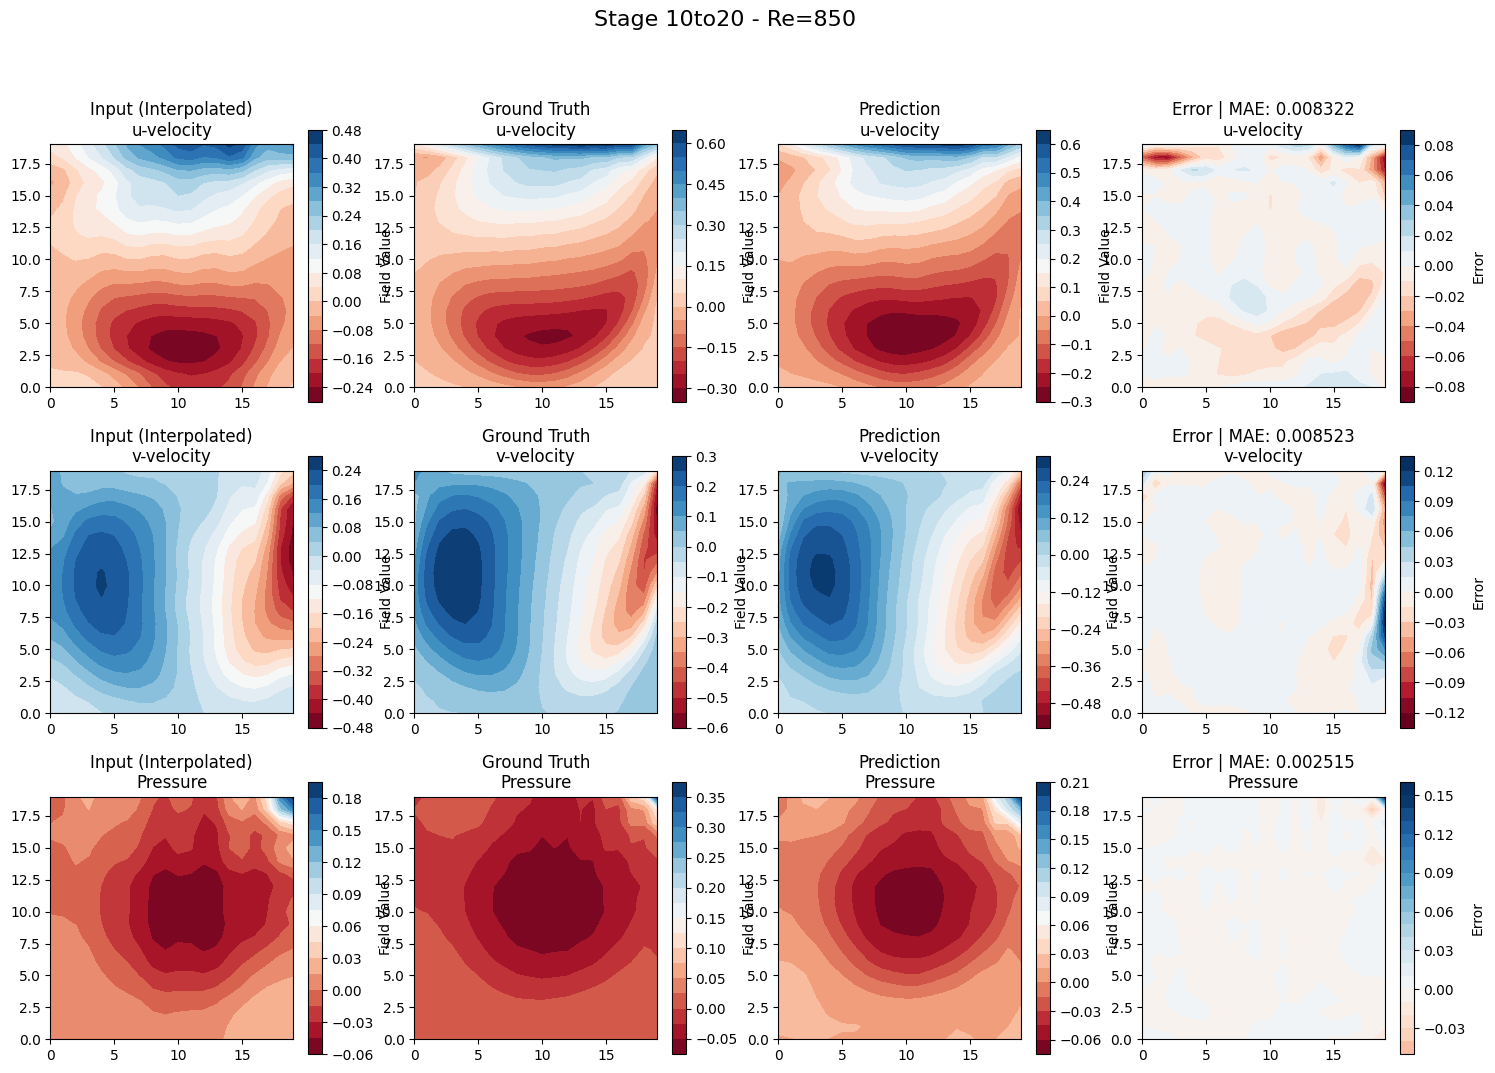

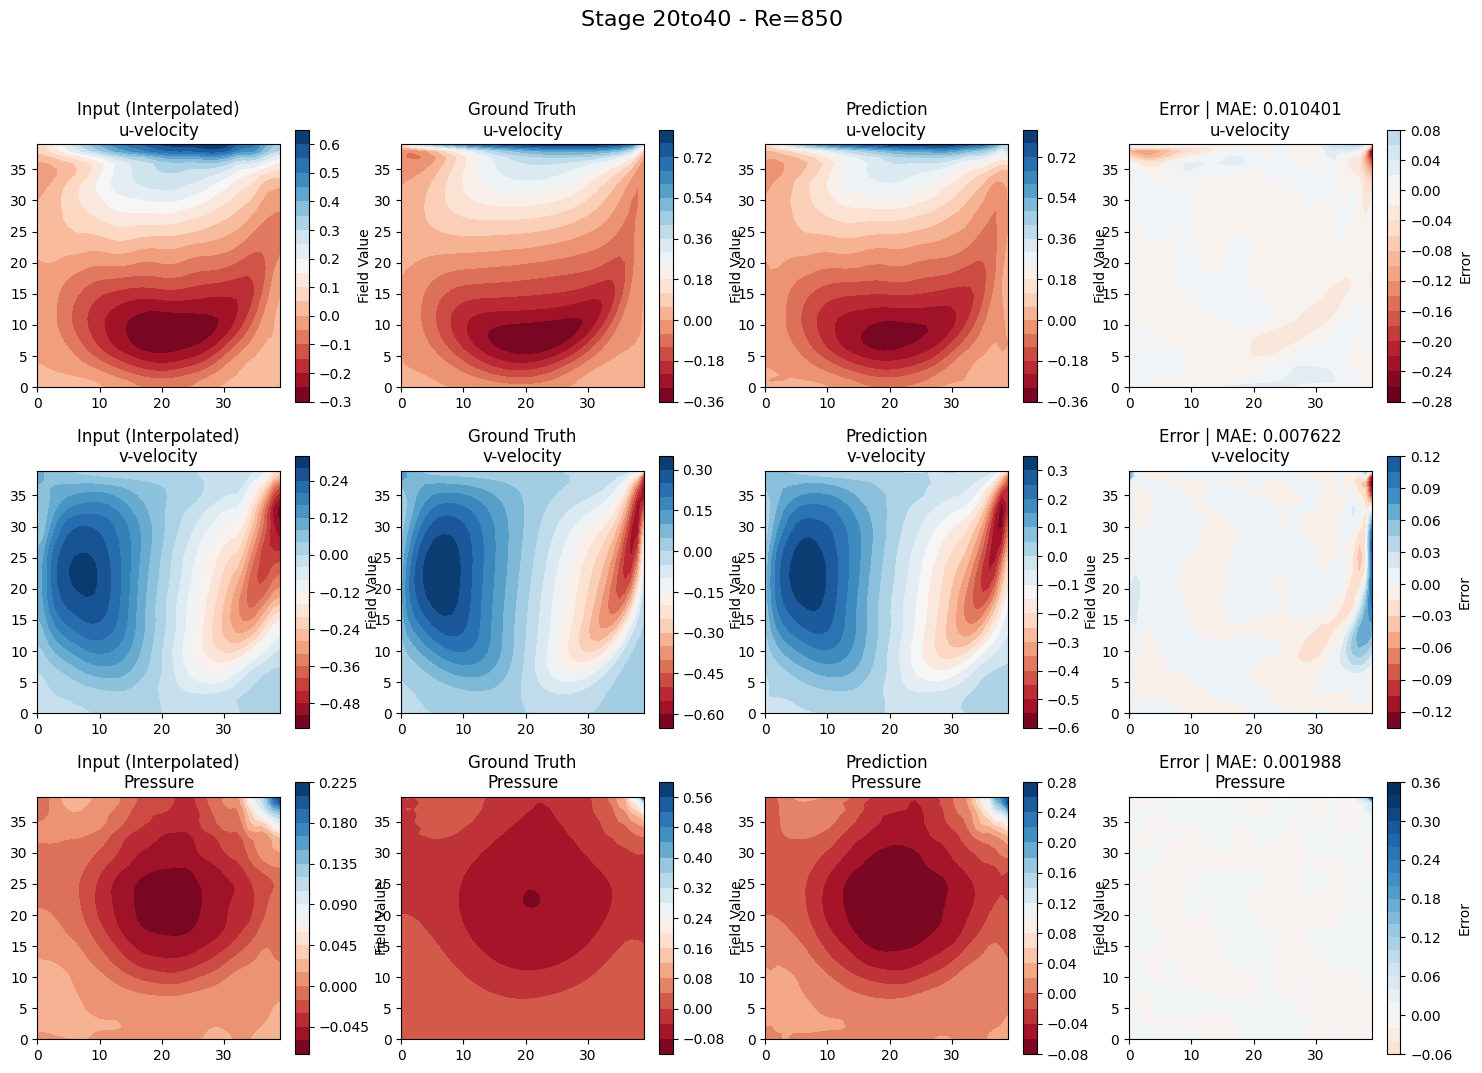

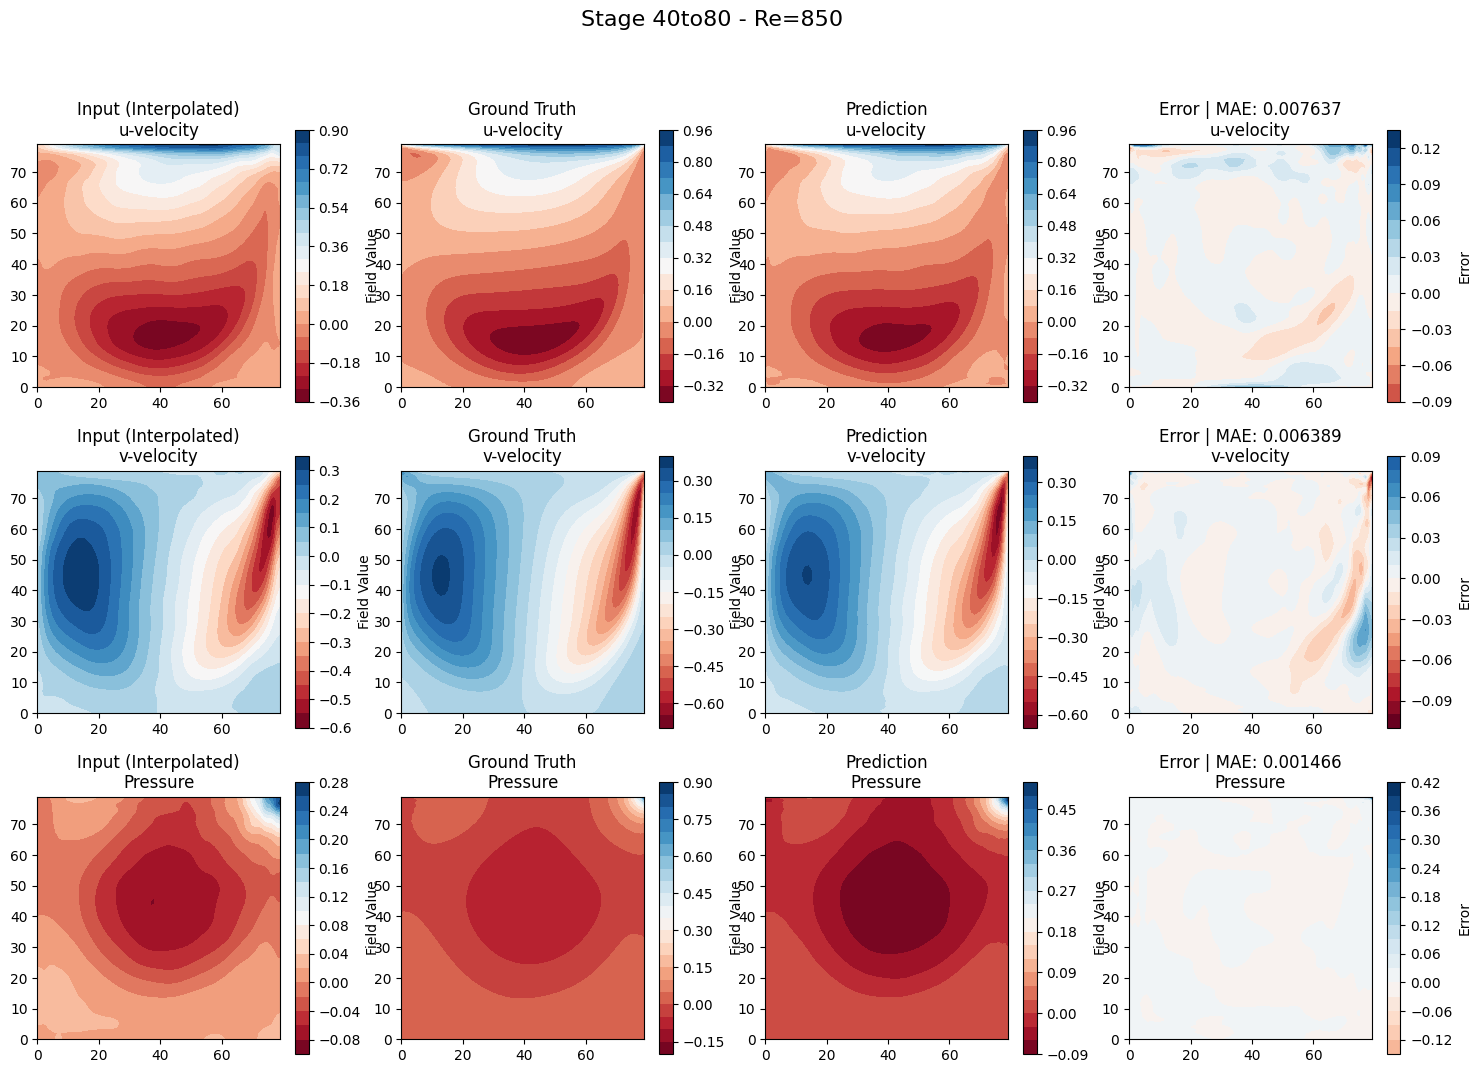

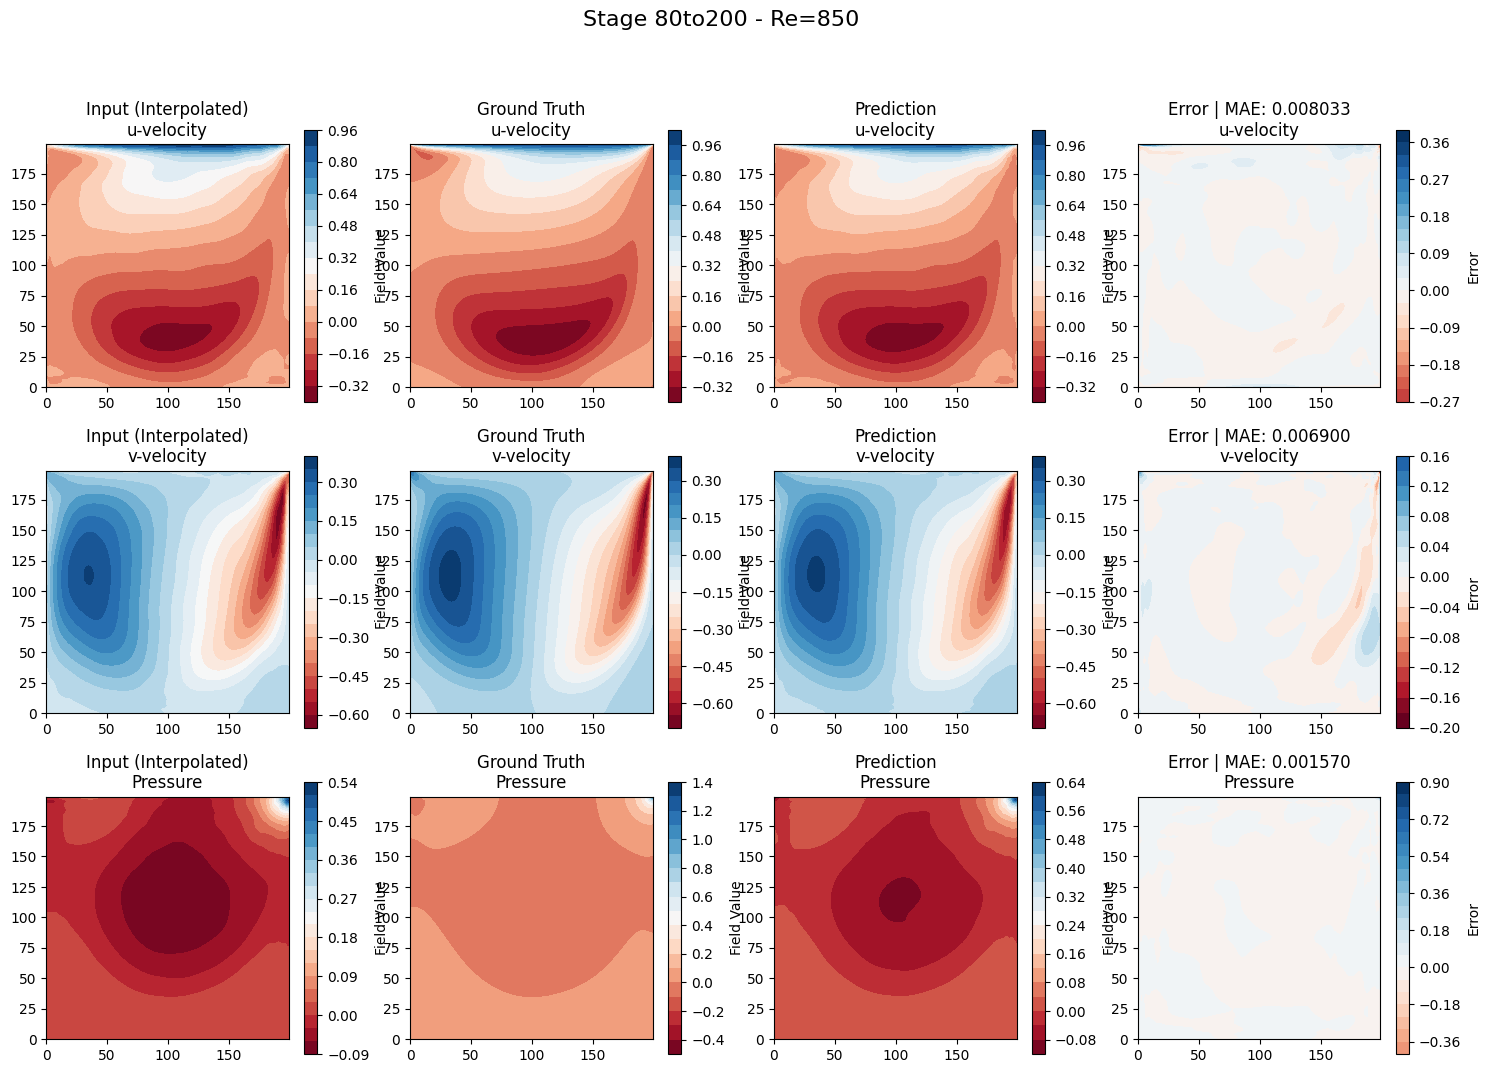

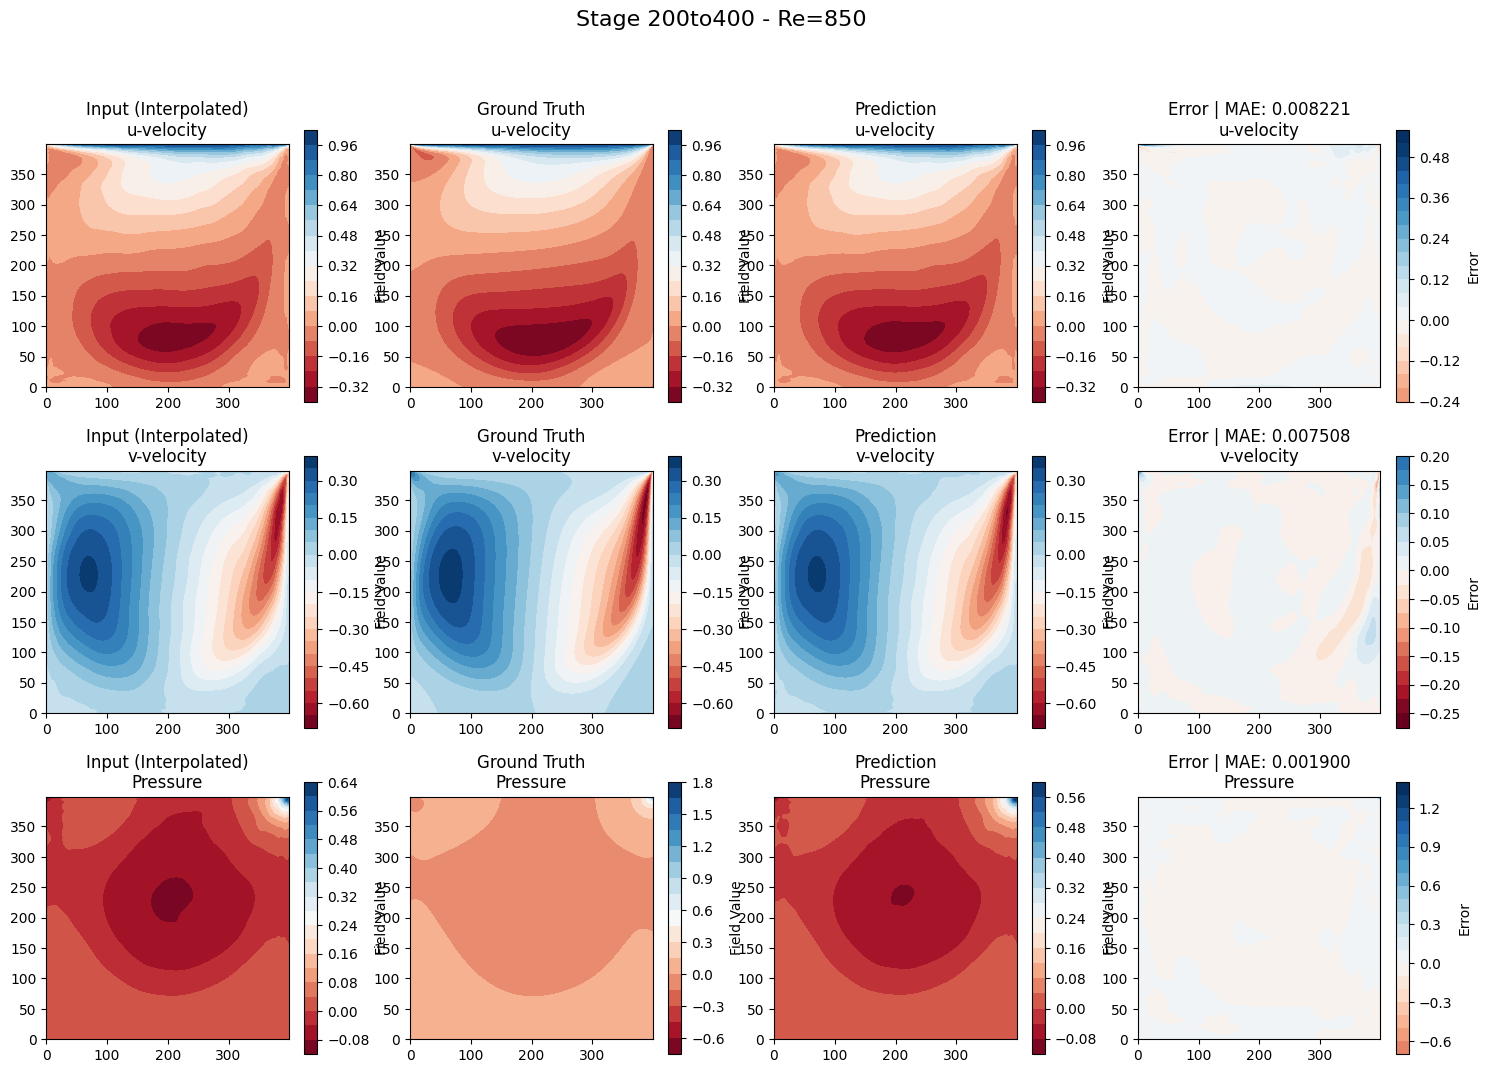

In [12]:
# Progressive Training Loop
print("\n" + "="*70)
print("🚀 STARTING PROGRESSIVE CASCADED TRAINING")
print("="*70)

trained_models = {}
stage_metrics = {}

# Train each stage sequentially
for stage_idx, (target_dim, epochs) in enumerate(zip(STAGE_DIMS, EPOCHS_PER_STAGE)):
    # Determine input dimension (previous stage output or initial LR)
    if stage_idx == 0:
        input_dim = LR_DIM
    else:
        input_dim = STAGE_DIMS[stage_idx - 1]
    
    stage_name = f"{input_dim}to{target_dim}"
    
    # Build U-Net for this stage
    unet = build_residual_unet(
        input_shape=(target_dim, target_dim, 3),
        base_filters=BASE_FILTERS,
        depth=UNET_DEPTH,
        activation=ACTIVATION
    )
    
    # Wrap in interpolate-refine model
    stage_model = InterpolateRefineModel(
        unet_model=unet,
        target_size=(target_dim, target_dim),
        name=f"stage_{stage_name}"
    )
    
    # Prepare input: if not first stage, use previous stage's output
    if stage_idx == 0:
        # First stage: use ground truth input at input_dim
        x_train_input = train_data_norm[input_dim]
        x_test_input = test_data_norm[input_dim]
    else:
        # Subsequent stages: use previous stage's predictions as input
        # This ensures progressive refinement: 10→20→40→80→200→400
        prev_model = trained_models[STAGE_DIMS[stage_idx - 1]]
        
        # Chain from the actual previous input (NOT from LR_DIM every time!)
        if stage_idx == 1:
            # Stage 2 (20→40): Takes stage 1's output (from 10×10 input)
            prev_input_train = train_data_norm[LR_DIM]
            prev_input_test = test_data_norm[LR_DIM]
        else:
            # Later stages: Take the previous stage's output as stored
            # This variable will be updated at the end of each iteration
            prev_input_train = x_train_input_prev
            prev_input_test = x_test_input_prev
        
        x_train_input = prev_model.predict(prev_input_train, verbose=0)
        x_test_input = prev_model.predict(prev_input_test, verbose=0)
        
        print(f"   📊 Generated input from previous stage: {x_train_input.shape}")
    
    x_train_target = train_data_norm[target_dim]
    x_test_target = test_data_norm[target_dim]
    
    # Store current inputs for next stage (progressive chaining)
    x_train_input_prev = x_train_input
    x_test_input_prev = x_test_input
    
    # Train stage
    train_stage(
        model=stage_model,
        x_input=x_train_input,
        x_target=x_train_target,
        epochs=epochs,
        batch_size=BATCH_SIZE,
        loss_config=LOSS_CONFIG,
        stage_name=stage_name
    )
    
    # Evaluate stage
    metrics = evaluate_stage(
        model=stage_model,
        x_input=x_test_input,
        x_target=x_test_target,
        stats=norm_stats,
        stage_name=stage_name
    )
    
    # Store results
    trained_models[target_dim] = stage_model
    stage_metrics[stage_name] = metrics
    
    # Save stage model
    stage_model.unet.save(f"unet_stage_{stage_name}_{OTHER_DETAILS}.h5")
    print(f"\n💾 Saved U-Net for stage {stage_name}")
    
    # Plot sample if enabled
    if PLOT_SAMPLES:
        pred_test = stage_model.predict(x_test_input, verbose=0)
        plot_comparison(
            input_lr=x_test_input,
            target_hr=x_test_target,
            pred_hr=pred_test,
            sample_idx=0,
            stage_name=stage_name,
            stats=norm_stats,
            reynolds_num=test_reynolds[0]
        )

print("\n" + "="*70)
print("✅ ALL STAGES TRAINED SUCCESSFULLY")
print("="*70)


📊 FINAL EVALUATION: Full Pipeline (10×10  to  400×400)

🎯 Final Test Set Performance:
   MAE (u-velocity): 0.008833
   MAE (v-velocity): 0.007148
   MAE (pressure):   0.002438
   MAE (average):    0.006140


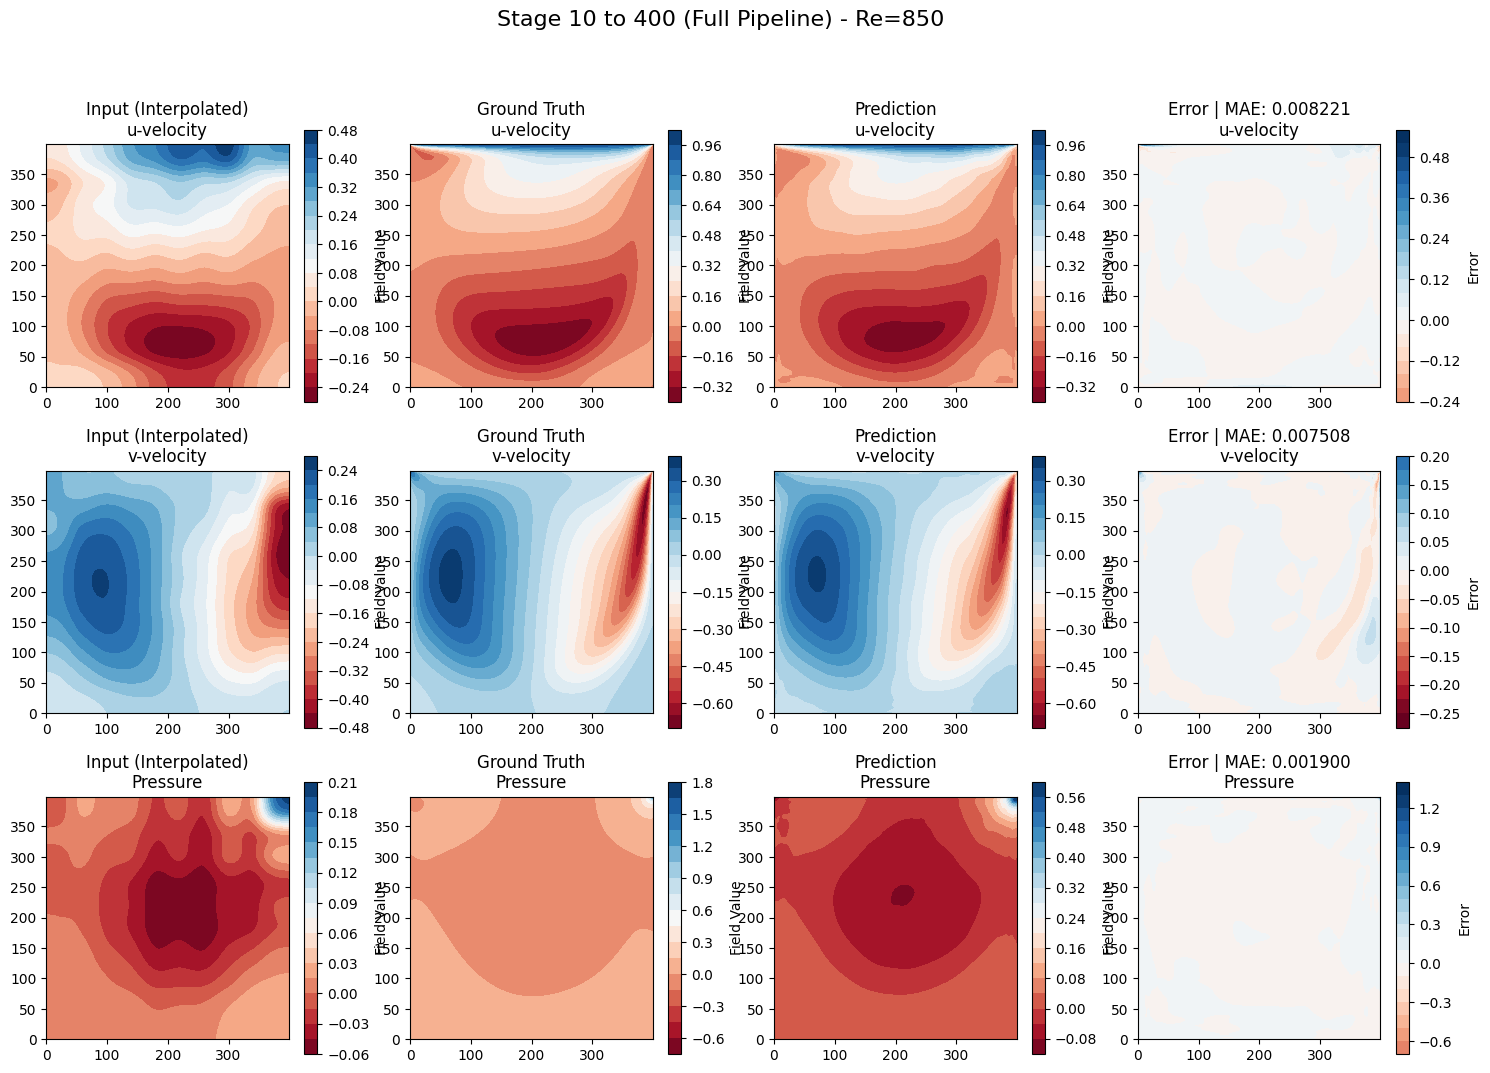

In [13]:
# Final Evaluation: Full Pipeline (10 -> 400)
print("\n" + "="*70)
print("📊 FINAL EVALUATION: Full Pipeline (10×10  to  400×400)")
print("="*70)

# Run full cascade on test data
x_current = test_data_norm[LR_DIM]

for target_dim in STAGE_DIMS:
    x_current = trained_models[target_dim].predict(x_current, verbose=0)

# Final prediction is x_current at 400x400
final_pred_norm = x_current
final_target_norm = test_data_norm[400]

# Denormalize and compute metrics
final_pred_real = denormalize_with_stats(final_pred_norm, norm_stats)
final_target_real = denormalize_with_stats(final_target_norm, norm_stats)

mae_u = np.mean(np.abs(final_target_real[..., 0] - final_pred_real[..., 0]))
mae_v = np.mean(np.abs(final_target_real[..., 1] - final_pred_real[..., 1]))
mae_p = np.mean(np.abs(final_target_real[..., 2] - final_pred_real[..., 2]))
mae_total = np.mean([mae_u, mae_v, mae_p])

print(f"\n🎯 Final Test Set Performance:")
print(f"   MAE (u-velocity): {mae_u:.6f}")
print(f"   MAE (v-velocity): {mae_v:.6f}")
print(f"   MAE (pressure):   {mae_p:.6f}")
print(f"   MAE (average):    {mae_total:.6f}")

# Plot final comparison
if PLOT_SAMPLES:
    plot_comparison(
        input_lr=test_data_norm[LR_DIM],
        target_hr=final_target_norm,
        pred_hr=final_pred_norm,
        sample_idx=0,
        stage_name="10 to 400 (Full Pipeline)",
        stats=norm_stats,
        reynolds_num=test_reynolds[0]
    )

In [14]:
# Save normalization statistics
print("\n💾 Saving normalization statistics...")
with open(f"norm_stats_{LR_DIM}to{STAGE_DIMS[-1]}_{OTHER_DETAILS}.txt", 'w') as f:
    f.write("# Per-channel Z-score normalization statistics\n")
    f.write("# Format: channel mean std\n")
    for ch in ['u', 'v', 'p']:
        mean, std = norm_stats[ch]
        f.write(f"{ch} {mean} {std}\n")

# Save metrics summary
with open(f"metrics_summary_{LR_DIM}to{STAGE_DIMS[-1]}_{OTHER_DETAILS}.txt", 'w') as f:
    f.write("# Progressive Cascaded Super-Resolution Metrics\n")
    f.write("# Stage-wise performance\n\n")
    for stage_name, metrics in stage_metrics.items():
        f.write(f"Stage: {stage_name}\n")
        f.write(f"  MAE (u): {metrics['mae_u']:.6f}\n")
        f.write(f"  MAE (v): {metrics['mae_v']:.6f}\n")
        f.write(f"  MAE (p): {metrics['mae_p']:.6f}\n")
        f.write(f"  MAE (avg): {metrics['mae_avg']:.6f}\n\n")
    
    f.write(f"\nFinal Pipeline Performance (10 to {STAGE_DIMS[-1]}x{STAGE_DIMS[-1]}x):\n")
    f.write(f"  MAE (u): {mae_u:.6f}\n")
    f.write(f"  MAE (v): {mae_v:.6f}\n")
    f.write(f"  MAE (p): {mae_p:.6f}\n")
    f.write(f"  MAE (avg): {mae_total:.6f}\n")

print("\n✅ All artifacts saved.")
print(f"\n{'='*70}")
print("🎉 TRAINING COMPLETE!")
print(f"{'='*70}")


💾 Saving normalization statistics...

✅ All artifacts saved.

🎉 TRAINING COMPLETE!
